In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
from statsmodels.api import OLS, add_constant


In [8]:
# load price data
price_data = pd.read_csv(
    "../data/prices.csv",
    index_col = 0,
    parse_dates = True
) 

price_data = price_data.dropna()
price_data.head()

,AAPL,MSFT
Date,,
2020-01-02,72.468277,152.505661
2020-01-03,71.763733,150.606735
2020-01-06,72.335556,150.995987
2020-01-07,71.995338,149.619263
2020-01-08,73.153503,152.002457


In [24]:
# Engle-Granger cointegration test (check if there is a long-term relationship between the 2 time series)
score, pvalue, _ = coint( 
    price_data["AAPL"],
    price_data["MSFT"]
)
# '_' is used as a "throwaway" variable, basically telling python that there is meant to be a parameter here, but to just ignore it.
    
print("Cointegration p-value: " , pvalue)

Cointegration p-value:  0.22061671275220174


### Interpretation of cointegration test
- p < 0.05  ->  cointegrated (which is good)
- p > 0.05  -> not cointegrated 

In [29]:
x = add_constant(price_data["MSFT"]) # Add a new column "const" of 1s
y = price_data["AAPL"]

model = OLS(y, x).fit() # Creates an Ordinary Least Squares regresson object, where .fit() finds the best line that fits the data y = c + β.X
beta = model.params["MSFT"] # Returns the β from the line of best fit, this is the slope coefficient for MSFT

print("Hedge ratio (beta):", beta)
print("This value tells us how much MSFT offsets AAPL which is quite a lot")


Hedge ratio (beta): 0.5708428264269434
This value tells us how much MSFT offsets AAPL which is quite a lot


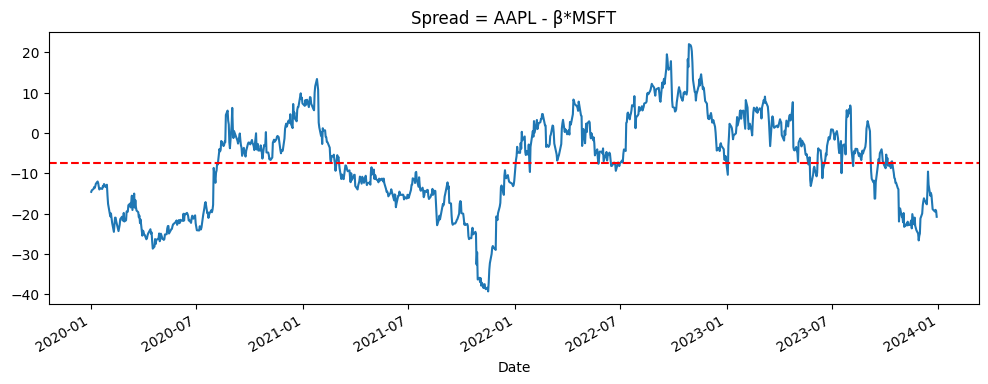

In [38]:
spread = price_data["AAPL"] - beta * price_data["MSFT"] # Spread formula, returns a table of each day's spread

# Plot the spread data
spread.plot(figsize = (12,4))
plt.title("Spread = AAPL - β*MSFT")
plt.axhline(spread.mean(), color = "red", linestyle = "--")
plt.show()


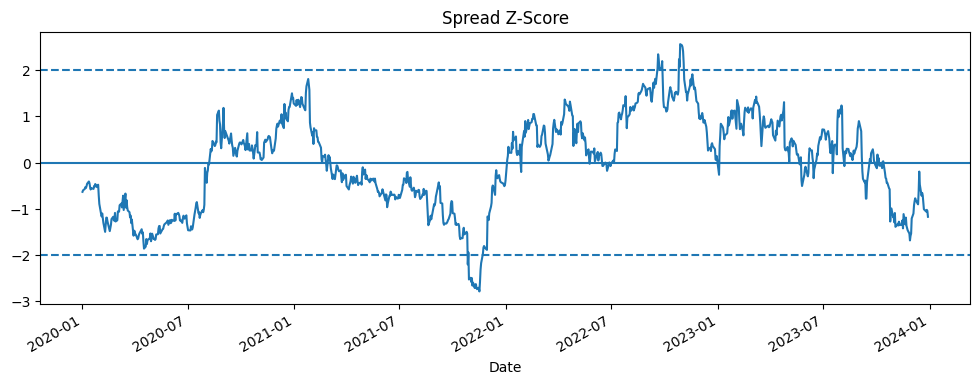

In [43]:
# Standardise the spread (z-score)
zscore = (spread- spread.mean())/spread.std()

# Plot standardised spread
zscore.plot(figsize = (12,4))
plt.axhline(2, linestyle = "--")
plt.axhline(-2, linestyle = "--")
plt.axhline(0)
plt.title("Spread Z-Score")
plt.show()

### When Z-score :
- z > +2 -> spread is too high, so should short spread ie short AAPL, long β.MSFT (as the spread is unusually high and the spread will return to normal values)
- z < -2 -> spread is too low, should long spread ie long AAPL and short β.MSFT

So we are betting on the stationarity of the spread, hoping that it will return to normal!